In [5]:
import os
import sys

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

In [6]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format='retina'


from src.text_utils import find_index_of_incongruent_word
from src.tokenizer_utils import load_tokenizer, tokenize

### Representation Similarity Analysis

Задача вычислить пространство представлений вычислением расстояний между стимулами в пространстве признаков

- признаковое простраство для модели - скрытые представления стимулов на каждом из слоев
- признаковое пространство для ЭЭГ - временные ряды значений потенциалов с датчиков

In [ ]:
rsa_files = [
    "src/results/Qwen_Qwen2.5-7B/stimuli_matrix_by_layer/rsa_json.json"
]

2025-11-08 18:43:57 DEBUG    matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x326b0e7b0>


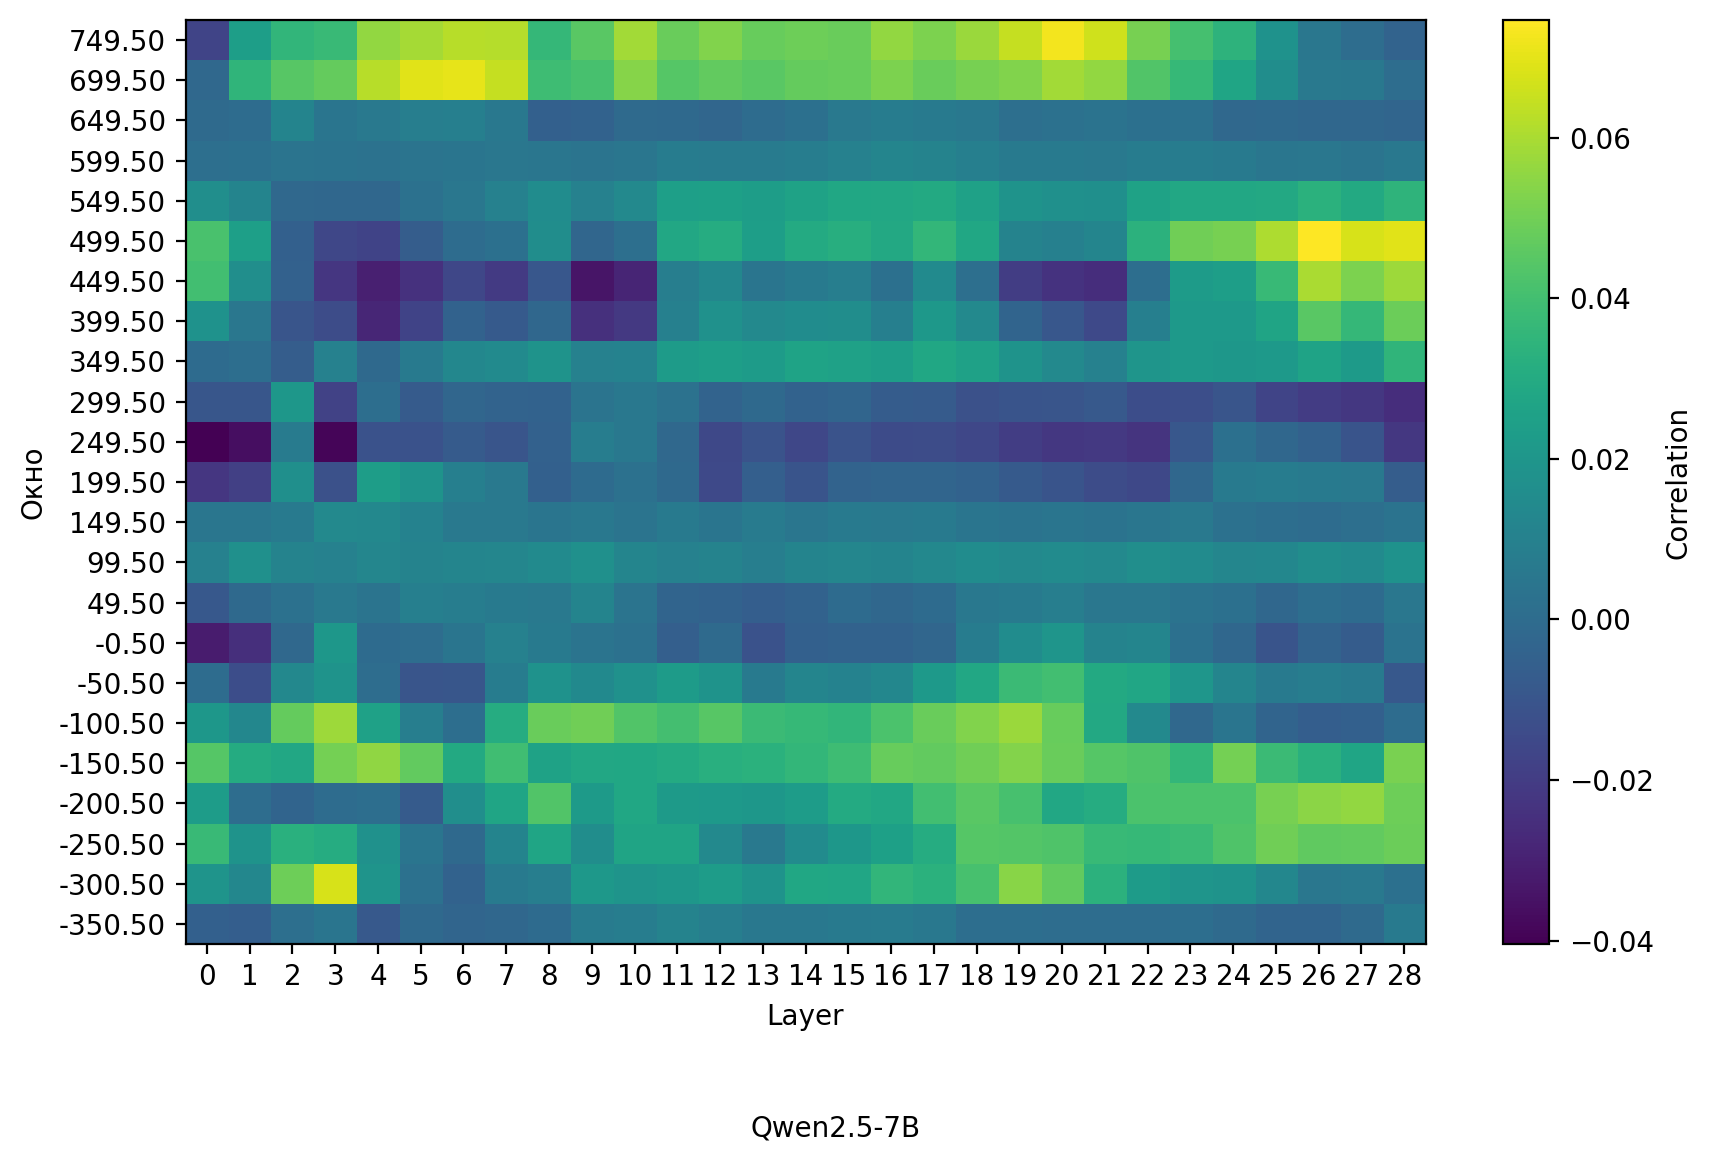

In [17]:

model_name = "Qwen2.5-7B"
with open("../src/results/Qwen_Qwen2.5-7B/stimuli_matrix_by_layer/rsa_json.json", "r") as f:
    data = json.load(f)

layers = sorted(data.keys(), key=lambda x: int(x))

cor_matrix = np.array([data[layer]["correlations"] for layer in layers]).T


time_axis = data[layers[0]]["window_centers"]

plt.figure(figsize=(10, 6))
im = plt.imshow(
    cor_matrix,
    aspect='auto',
    origin='lower',
    cmap='viridis'
)

plt.colorbar(im, label="Correlation")
plt.xlabel("Layer")
plt.ylabel("Окно")
plt.figtext(0.45, -0.05, model_name, ha="center")
plt.xticks(range(len(layers)), layers, rotation=0)
plt.yticks(range(len(time_axis)), [f"{(t * 1000):.2f}" for t in time_axis])

plt.show()
